In [76]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

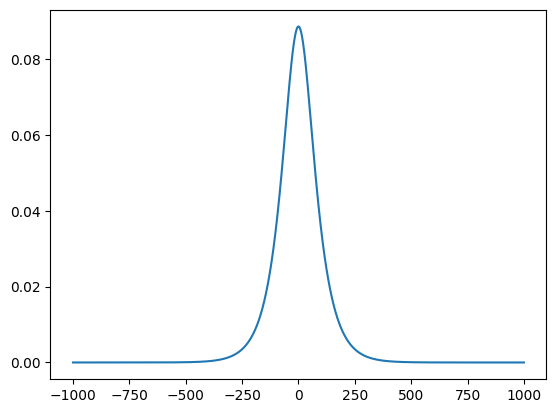

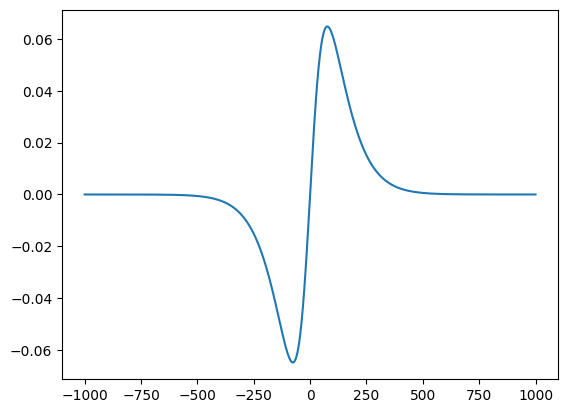

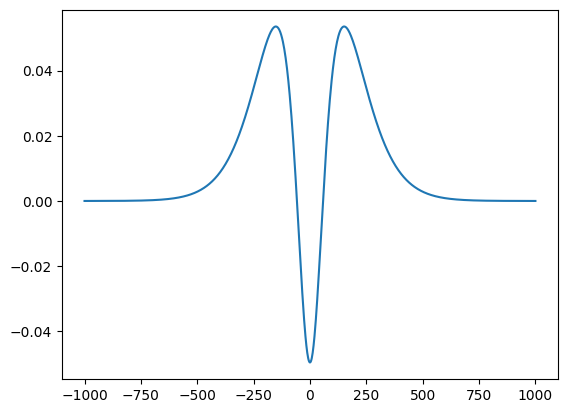

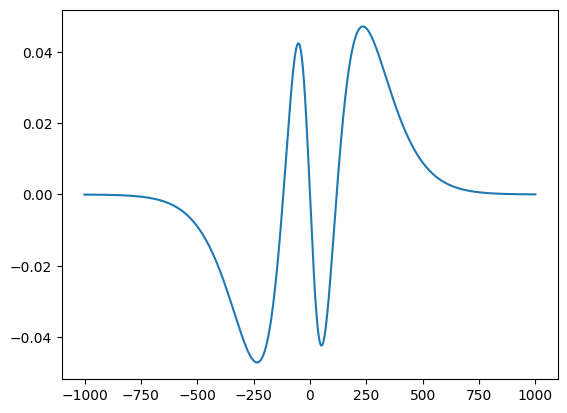

In [36]:
t = np.linspace(-1000, 1000, 1001)

for m in range(4):
    plt.plot(t, xi_m(t, m, kappa))
    plt.show()

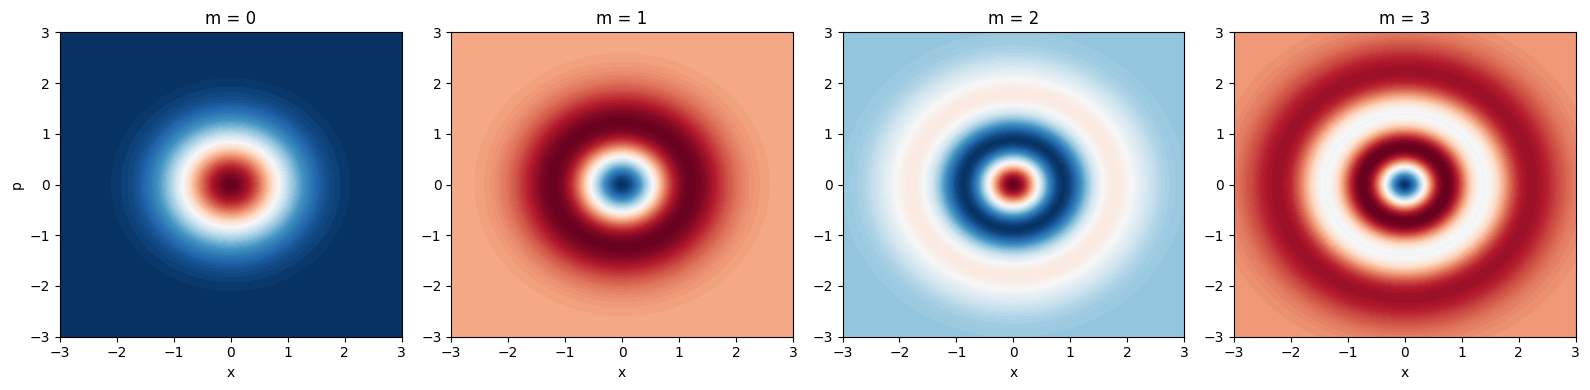

In [ ]:
from scipy.integrate import simpson
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, wigner

M = 10
xvec = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plt.subplots_adjust(wspace=0.3)

for n, ax in enumerate(axes):
    f_modes = [xi_m(t, m, kappa) for m in range(M)]
    f_target = xi_m(t, n, kappa)

    ci = np.array([simpson(f_modes[i].conj() * f_target, x=t) for i in range(M)])
    ci /= np.sqrt(np.sum(np.abs(ci)**2))

    psi = sum(ci[i] * basis(M, i) for i in range(M))
    rho = psi * psi.dag()

    W = wigner(rho, xvec, xvec)

    im = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    ax.set_title(f"m = {n}")
    ax.set_xlabel('x')
    if n == 0:
        ax.set_ylabel('p')

# cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, label='Wigner amplitude')
plt.tight_layout()
plt.show()


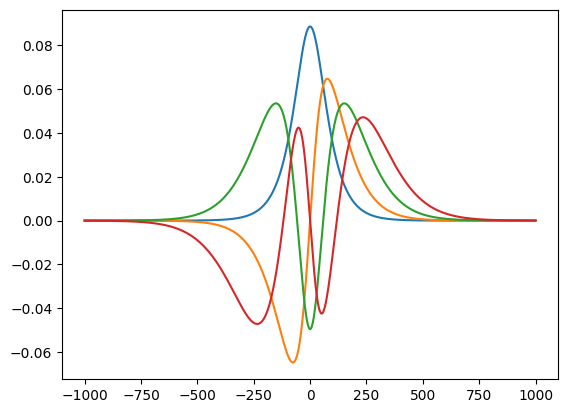

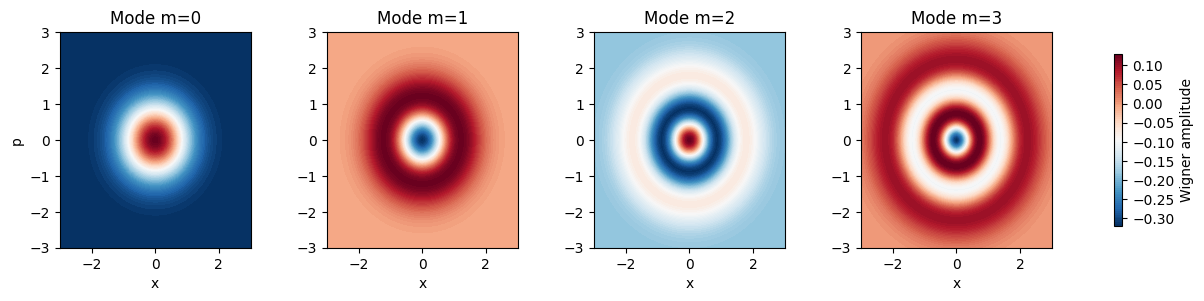

In [81]:

M = 20       
N_modes = 4  
kappa = 2.5e-3*2*np.pi*2
t = np.linspace(-1000, 1000, 1001)  # 時間分解能を大幅に上げる

xvec = np.linspace(-3, 3, 300)
for i in range(4):
    plt.plot(t, xi_m(t, i, kappa))
plt.show()

fig, axes = plt.subplots(1, N_modes, figsize=(16, 2.8))
plt.subplots_adjust(wspace=0.4)

for n, ax in enumerate(axes):
    f_modes = [xi_m(t, m, kappa) for m in range(M)]
    f_target = xi_m(t, n, kappa)

    ci = np.array([simpson(np.conj(f_modes[i]) * f_target, x=t) for i in range(M)])
    ci /= np.sqrt(np.sum(np.abs(ci)**2)) 

    psi = sum(ci[i] * basis(M, i) for i in range(M))
    rho = psi * psi.dag()

    W = wigner(rho, xvec, xvec)

    im = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    ax.set_title(f"Mode m={n}")
    ax.set_xlabel('x')
    if n == 0:
        ax.set_ylabel('p')

fig.colorbar(im, ax=axes.ravel(), shrink=0.8, label='Wigner amplitude')
plt.show()


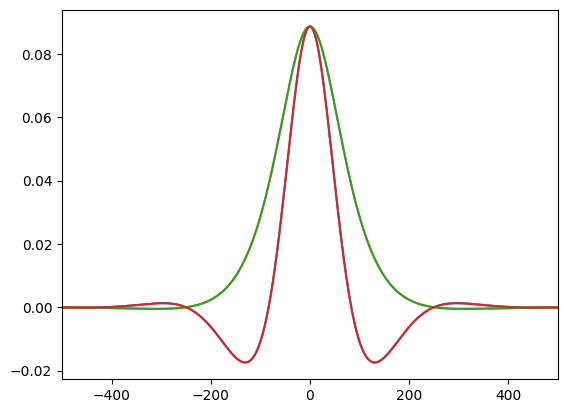

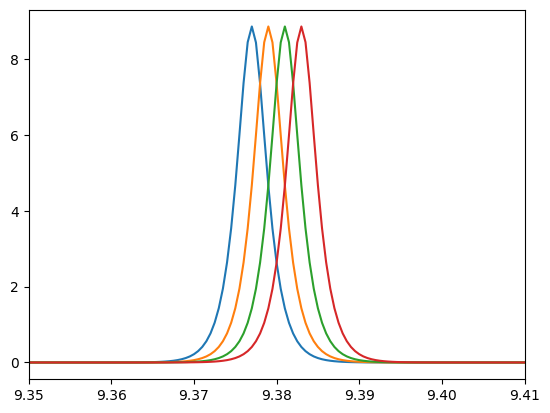

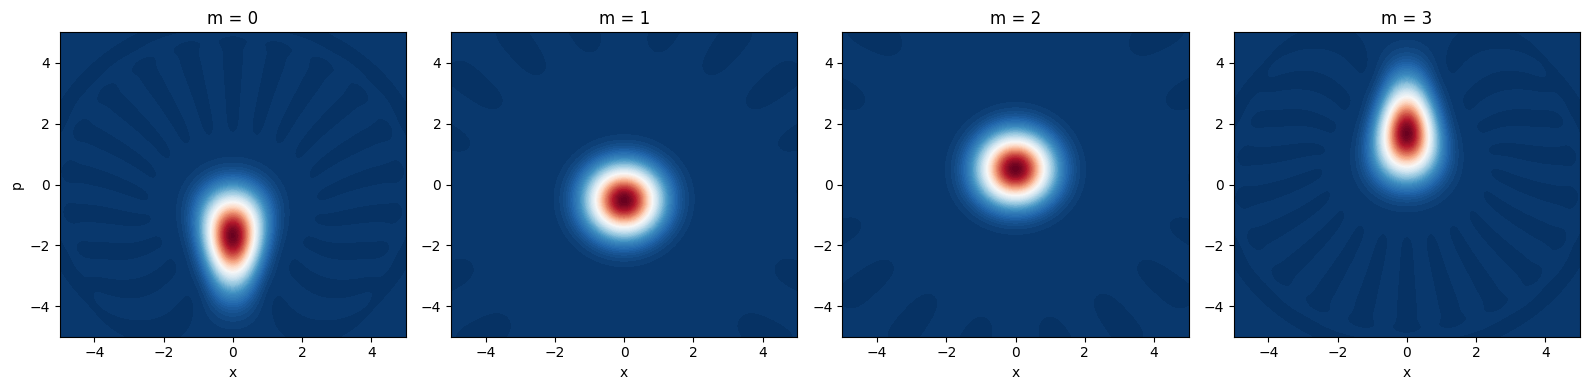

In [95]:
from scipy.fft import fft, fftfreq, fftshift
delta_freq = 0.002 
n_max = 4
def xi_m_freqbin(t, m, delta_freq, kappa, n_max):
    t = np.asarray(t, dtype=np.float64)
    base_waveform = np.asarray(xi_m(t, 0, kappa), dtype=np.complex128)
    center = (n_max-1) / 2

    freq_shift = float(delta_freq * (m - center))
    phase = np.exp(2j * np.pi * freq_shift * t)

    return base_waveform * phase
omega_0 = 9.38
dt = t[1] - t[0]

xi_funcs_f = []
freq_axis = fftshift(fftfreq(len(t), dt))+ omega_0 
for m in range(n_max+1):
    xi_t = xi_m_freqbin(t, m, delta_freq, kappa, n_max)
    xi_f = fftshift(fft(xi_t))
    xi_funcs_f.append(np.abs(xi_f))

M = 20
xvec = np.linspace(-5, 5, 200)
for i in range(4):
    plt.plot(t, xi_m_freqbin(t, i, delta_freq, kappa, n_max))
plt.xlim(-500, 500)
plt.show()

for i in range(4):
    plt.plot(freq_axis, xi_funcs_f[i])
plt.xlim(9.35, 9.41)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plt.subplots_adjust(wspace=0.3)

for n, ax in enumerate(axes):
    f_modes = [xi_m(t, m, kappa) for m in range(M)]
    f_target = xi_m_freqbin(t, n, delta_freq, kappa, n_max)

    ci = np.array([simpson(f_modes[i].conj() * f_target, x=t) for i in range(M)])
    ci /= np.sqrt(np.sum(np.abs(ci)**2))

    psi = sum(ci[i] * basis(M, i) for i in range(M))
    rho = psi * psi.dag()

    W = wigner(rho, xvec, xvec)

    im = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    ax.set_title(f"m = {n}")
    ax.set_xlabel('x')
    if n == 0:
        ax.set_ylabel('p')

# cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, label='Wigner amplitude')
plt.tight_layout()
plt.show()



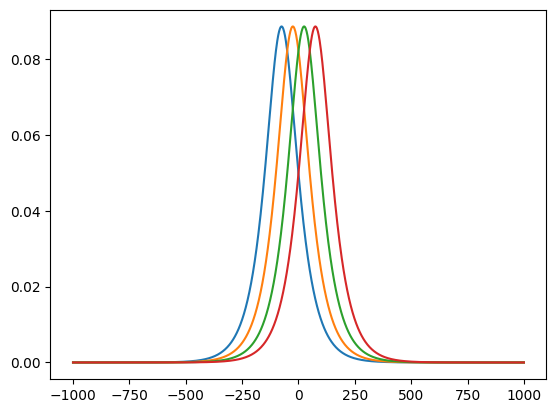

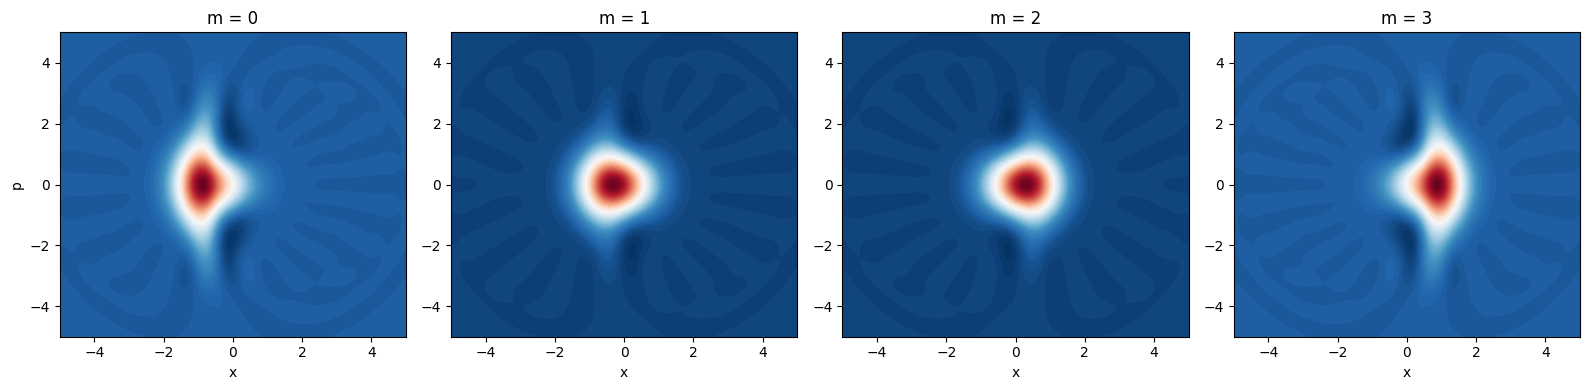

In [97]:
duration = 200
def xi_m_shifted(t, m, m_tot, kappa):
    shift = duration * (2 * m + 1 - m_tot) / (2 * m_tot)
    return xi_m(t - shift, 0, kappa)

for i in range(4):
    plt.plot(t, xi_m_shifted(t, i, 4, kappa))
# plt.xlim(-500, 500)
plt.show()

M = 20
xvec = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plt.subplots_adjust(wspace=0.3)

for n, ax in enumerate(axes):
    delta_freq = 0.002 
    n_max=8
    f_modes = [xi_m(t, m, kappa) for m in range(M)]
    f_target = xi_m_shifted(t, n, 4, kappa)

    ci = np.array([simpson(f_modes[i].conj() * f_target, x=t) for i in range(M)])
    ci /= np.sqrt(np.sum(np.abs(ci)**2))

    psi = sum(ci[i] * basis(M, i) for i in range(M))
    rho = psi * psi.dag()

    W = wigner(rho, xvec, xvec)

    im = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    ax.set_title(f"m = {n}")
    ax.set_xlabel('x')
    if n == 0:
        ax.set_ylabel('p')

# cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, label='Wigner amplitude')
plt.tight_layout()
plt.show()

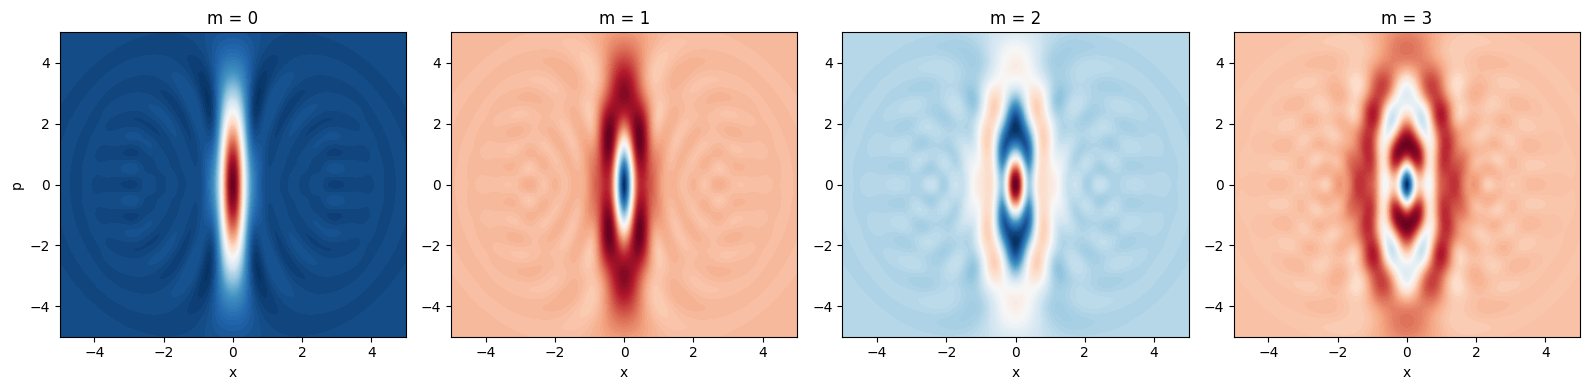

In [99]:
kappa_hermite =  1.5e-6*2*np.pi*2

def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return psi

M = 20
xvec = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plt.subplots_adjust(wspace=0.3)

for n, ax in enumerate(axes):
    f_modes = [hermite(t, m, kappa_hermite) for m in range(M)]
    f_target = xi_m(t, n, kappa)

    ci = np.array([simpson(f_modes[i].conj() * f_target, x=t) for i in range(M)])
    ci /= np.sqrt(np.sum(np.abs(ci)**2))

    psi = sum(ci[i] * basis(M, i) for i in range(M))
    rho = psi * psi.dag()

    W = wigner(rho, xvec, xvec)

    im = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    ax.set_title(f"m = {n}")
    ax.set_xlabel('x')
    if n == 0:
        ax.set_ylabel('p')

# cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, label='Wigner amplitude')
plt.tight_layout()
plt.show()
